In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))

if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
%load_ext autoreload
%autoreload 2
# the above two lines enable automatic reloading of modules

from config import config
import pandas as pd
from data.data_loader import get_dataloader, MNISTDataset
from data.data_loader import get_dataloader, FashionMNISTDataset
from models.models import Model
from utils.visualization import plot_confusion_matrix
import torch
from models.models import Model
import torch
import matplotlib.pyplot as plt

In [3]:
train_dataloader = get_dataloader(MNISTDataset('train'))
val_dataloader = get_dataloader(MNISTDataset('val'))
print("Train size", len(train_dataloader.dataset))
print("Val size", len(val_dataloader.dataset))


Train size 50000
Val size 10000


In [4]:
models = {"A": [], "B": [], "C": []}
for residual_type in ["A", "B", "C"]:
    model = Model.get_with_device(residual_type=residual_type)
    err, acc = model.evaluate(dataloader=val_dataloader)
    print(f"Initial evaluation for Residual Block {residual_type} - Error: {err}, Accuracy: {acc}")
    models[residual_type].append(model)

Initial evaluation for Residual Block A - Error: 2.302583172607422, Accuracy: 10.3
Initial evaluation for Residual Block B - Error: 2.3030246955871583, Accuracy: 10.09
Initial evaluation for Residual Block C - Error: 2.3034462188720704, Accuracy: 9.83


In [5]:
for residual_type, model_list in models.items():
    model = model_list[0]
    results = model.run_train(config.Epochs, train_dataloader, val_data=val_dataloader, verbose=False)
    err, acc = model.evaluate(dataloader=val_dataloader)
    print(f"Post-training evaluation for Residual Block {residual_type} - Error: {err}, Accuracy: {acc}")
    model_list.append(results)

Post-training evaluation for Residual Block A - Error: 0.026349919596035033, Accuracy: 99.2
Post-training evaluation for Residual Block B - Error: 0.04575572045119479, Accuracy: 98.74
Post-training evaluation for Residual Block C - Error: 0.09860535553861409, Accuracy: 97.42


In [6]:
def plot_graphs(data: list[tuple[str, list[dict]]], save_path: str = None):
    plt.figure(figsize=(10, 8))

    for residual, train_results in data:
        plt.subplot(2, 2, 1)
        plt.plot([i['train_loss'] for i in train_results] , label=residual)
        plt.subplot(2, 2, 2)
        plt.plot([i['train_acc'] for i in train_results] , label=residual)
        plt.subplot(2, 2, 3)
        plt.plot([i['val_loss'] for i in train_results] , label=residual)
        plt.subplot(2, 2, 4)
        plt.plot([i['val_acc'] for i in train_results] , label=residual)

    plt.subplot(2, 2, 1)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    if len(data) > 1:
        plt.legend()

    plt.subplot(2, 2, 2)
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    if len(data) > 1:
        plt.legend()

    plt.subplot(2, 2, 3)
    plt.title('Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    if len(data) > 1:
        plt.legend()

    plt.subplot(2, 2, 4)
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    if len(data) > 1:
        plt.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)

\begin{tabular}{lrrrr}
\toprule
Epoch & train\_loss & train\_acc & val\_loss & val\_acc \\
\midrule
0 & 0.155060 & 95.310000 & 0.058931 & 98.360000 \\
1 & 0.055143 & 98.426000 & 0.025974 & 99.240000 \\
2 & 0.046224 & 98.662000 & 0.023006 & 99.380000 \\
3 & 0.039257 & 98.890000 & 0.020706 & 99.430000 \\
4 & 0.035947 & 98.968000 & 0.026350 & 99.200000 \\
\bottomrule
\end{tabular}



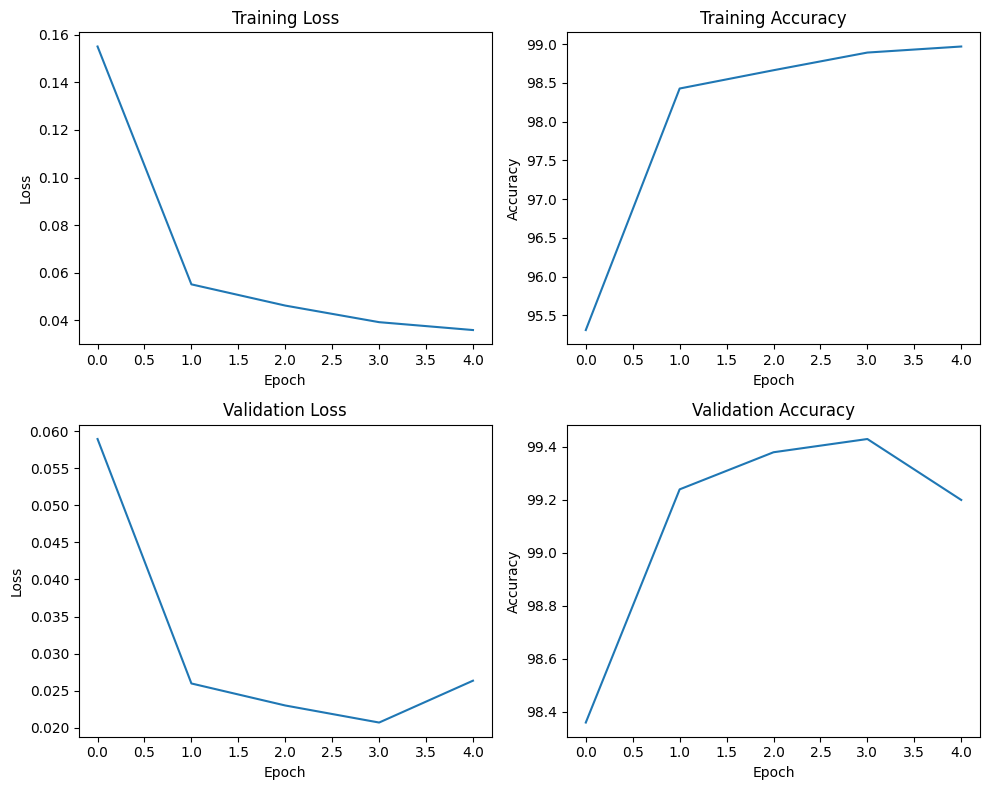

In [7]:
print(pd.DataFrame(models["A"][1]).to_latex().replace('_', '\\_').replace(' & t', 'Epoch & t', 1))
plot_graphs([('A', models['A'][1])], save_path = '../../report/images/q2a.jpg')

\begin{tabular}{lrrrr}
\toprule
Epoch & train\_loss & train\_acc & val\_loss & val\_acc \\
\midrule
0 & 0.426373 & 85.952000 & 0.157498 & 95.360000 \\
1 & 0.130969 & 96.054000 & 0.078504 & 97.440000 \\
2 & 0.103298 & 96.940000 & 0.061154 & 98.210000 \\
3 & 0.092428 & 97.144000 & 0.046544 & 98.730000 \\
4 & 0.086451 & 97.344000 & 0.045756 & 98.740000 \\
\bottomrule
\end{tabular}



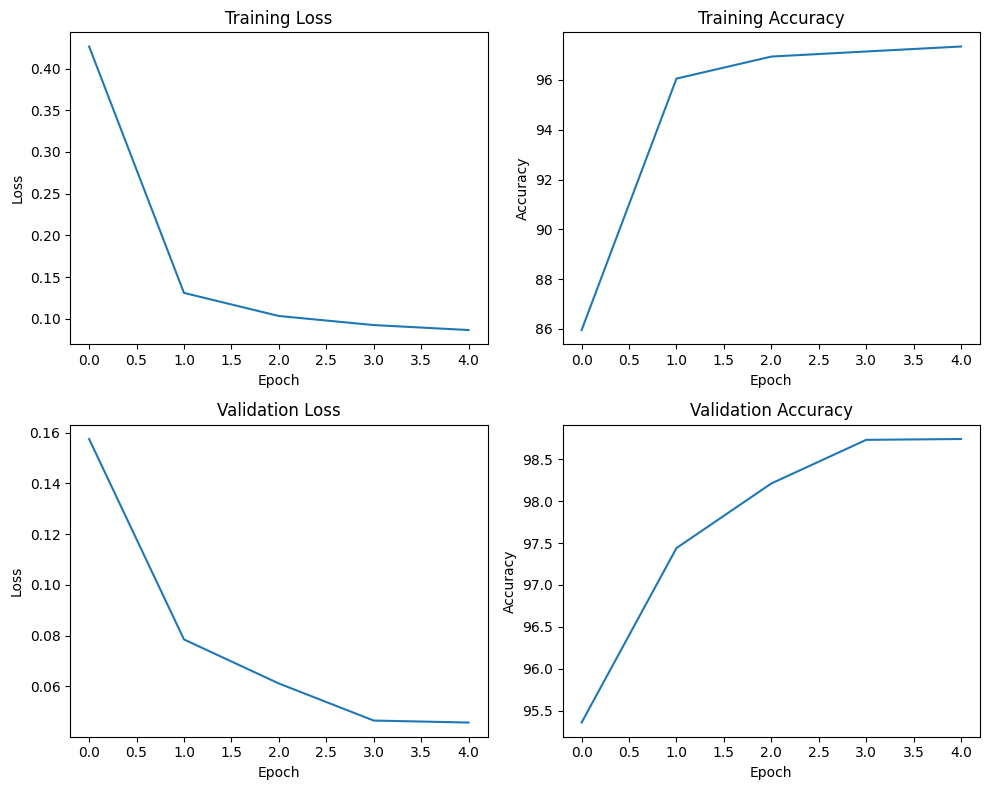

In [8]:
print(pd.DataFrame(models["B"][1]).to_latex().replace('_', '\\_').replace(' & t', 'Epoch & t', 1))
plot_graphs([('B', models['B'][1])], save_path= "../../report/images/q2b.jpg")

\begin{tabular}{lrrrr}
\toprule
Epoch & train\_loss & train\_acc & val\_loss & val\_acc \\
\midrule
0 & 0.486524 & 83.976000 & 0.182243 & 94.850000 \\
1 & 0.162272 & 95.110000 & 0.062752 & 98.140000 \\
2 & 0.123943 & 96.212000 & 0.063555 & 98.000000 \\
3 & 0.103672 & 96.802000 & 0.075380 & 97.740000 \\
4 & 0.095231 & 97.052000 & 0.098605 & 97.420000 \\
\bottomrule
\end{tabular}



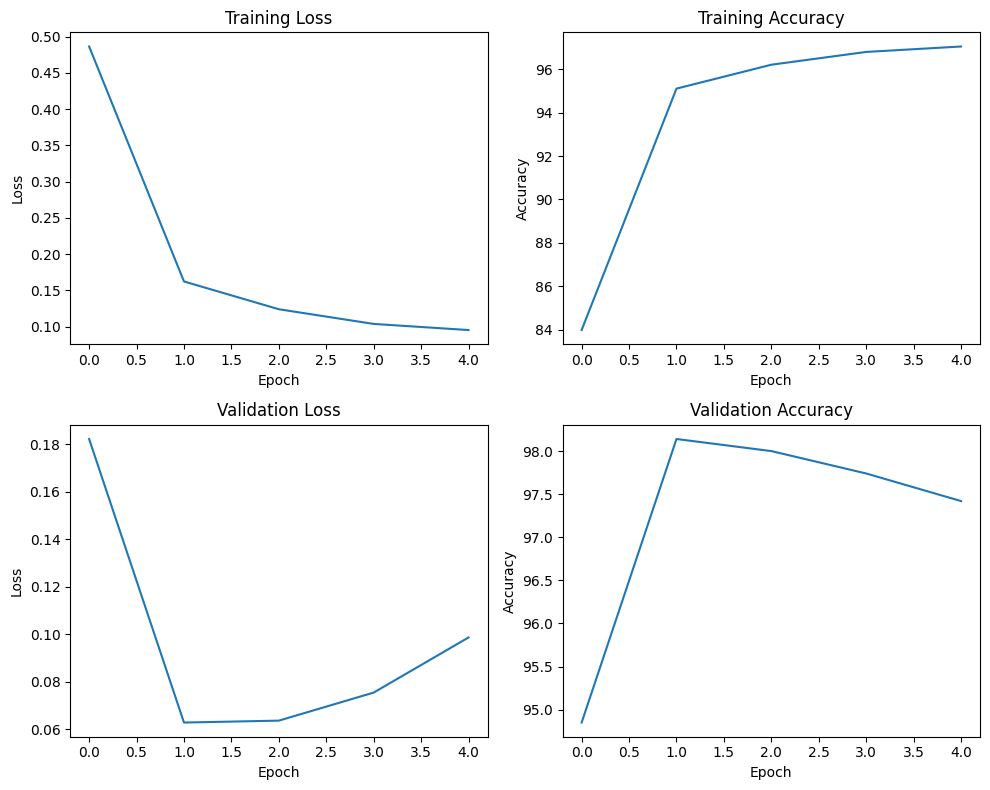

In [9]:
print(pd.DataFrame(models["C"][1]).to_latex().replace('_', '\\_').replace(' & t', 'Epoch & t', 1))
plot_graphs([('C', models['C'][1])], save_path= "../../report/images/q2c.jpg")

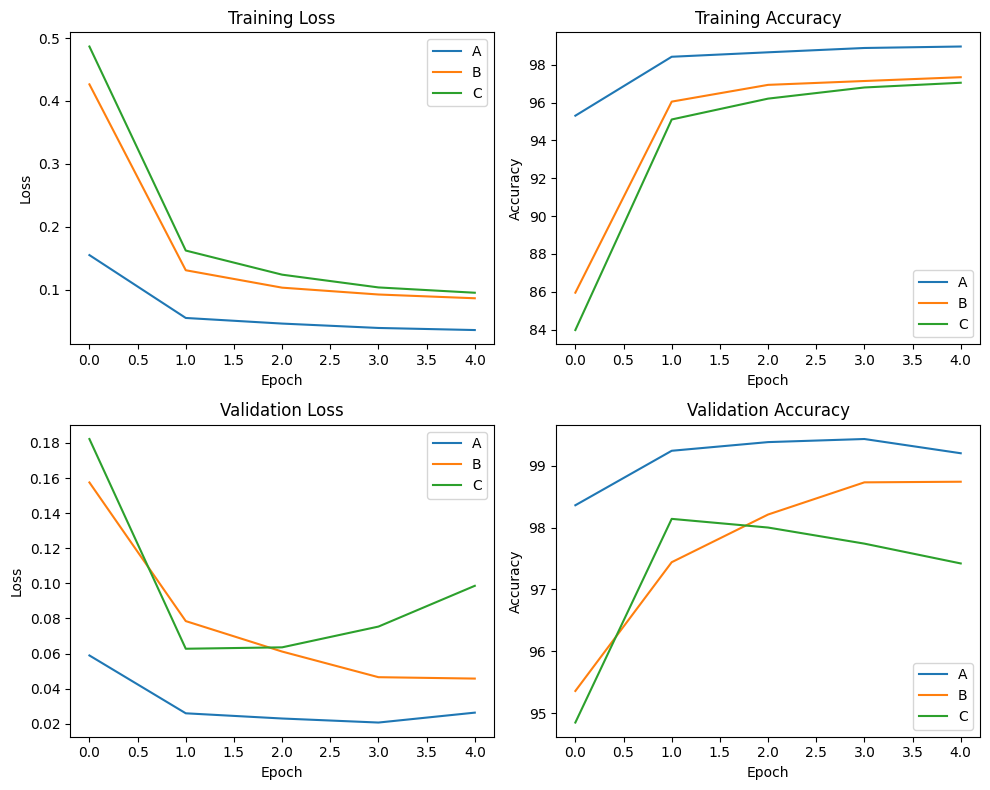

In [10]:
plot_graphs([(i, models[i][1]) for i in models.keys()], save_path = '../../report/images/q2all.jpg')

In [11]:
test_dataloader = get_dataloader(MNISTDataset("test"))
for residual in ("A", "B", "C"):
    model = models[residual][0]
    _, train_acc = model.evaluate(dataloader=train_dataloader)
    _, val_acc = model.evaluate(dataloader=val_dataloader)
    _, test_acc = model.evaluate(dataloader=test_dataloader)
    print(f"${test_acc}$ & ${val_acc}$ & ${train_acc}$ \\\\")

$99.27$ & $99.2$ & $98.068$ \\
$98.72$ & $98.74$ & $96.512$ \\
$97.07$ & $97.42$ & $97.042$ \\


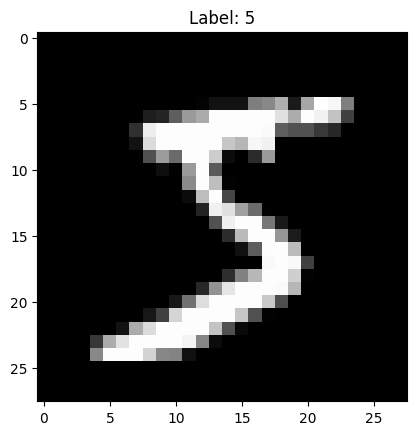

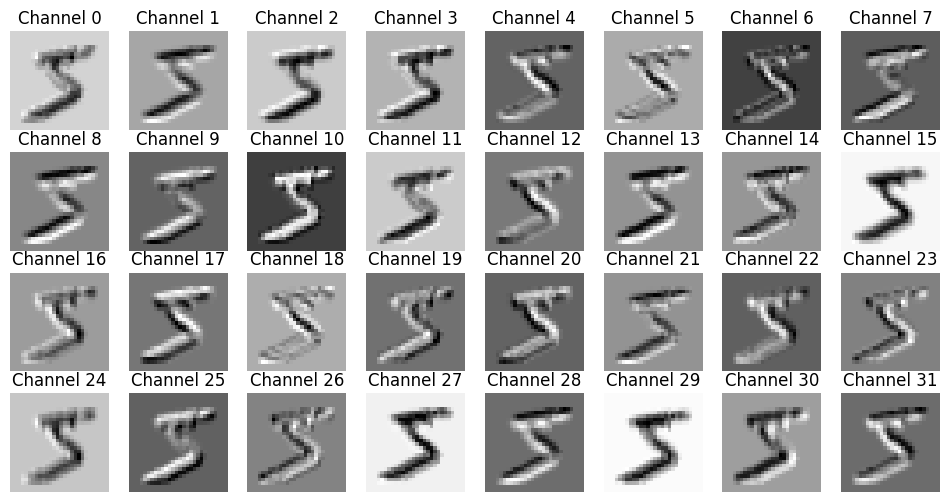

In [12]:
img, label = MNISTDataset("train")[0]
plt.imshow(img[0, :, :], cmap='gray')
plt.title(f"Label: {label}")
plt.savefig( "../../report/images/q2first_layer_orig.jpg")
plt.show()

model = models["A"][0]

input_tensor = torch.from_numpy(img).unsqueeze(0).to(model.device)

model.eval()
with torch.no_grad():
    first_layer_output = model.features[0](input_tensor)

assert first_layer_output.shape == (1, 32, 28, 28)
rows = 4
cols = 8
plt.figure(figsize=(12, 6))
for i in range(rows):
    for j in range(cols):
        channel_img = first_layer_output[0, i * cols + j, :, :]
        channel_img = channel_img.detach().cpu().numpy()
        plt.subplot(rows, cols, i * cols + j + 1)
        plt.imshow(channel_img, cmap='gray')
        plt.title(f"Channel {i * cols + j}")
        plt.axis('off')
plt.savefig( "../../report/images/q2first_layer_chans.jpg")
plt.show()

In [13]:
model = models["A"][0]
torch.save(model.state_dict(), "../models/saved_models/model_weights.pth")

In [14]:


train_dataloader = get_dataloader(FashionMNISTDataset("train"))
val_dataloader = get_dataloader(FashionMNISTDataset("val"))
test_dataloader = get_dataloader(FashionMNISTDataset("test"))



In [15]:
fashion_results = {}
for residual in models:
    model = models[residual][0]
    torch.save(model.state_dict(), f"../models/saved_models/{residual}_weights.pth")

    print(f"Initial {residual}:", model.evaluate(test_dataloader))
    model.freeze()
    results = model.run_train(10, train_dataloader, val_dataloader, verbose = False)
    fashion_results[residual] = results
    print(f"After fine-tuning {residual}:", model.evaluate(test_dataloader))

Initial A: (4.923588260650635, 15.01)
After fine-tuning A: (1.0421565860748292, 62.86)
Initial B: (7.717438031768799, 12.19)
After fine-tuning B: (1.3688564968109131, 50.0)
Initial C: (9.847147927856446, 10.37)
After fine-tuning C: (1.5713003074645997, 48.43)


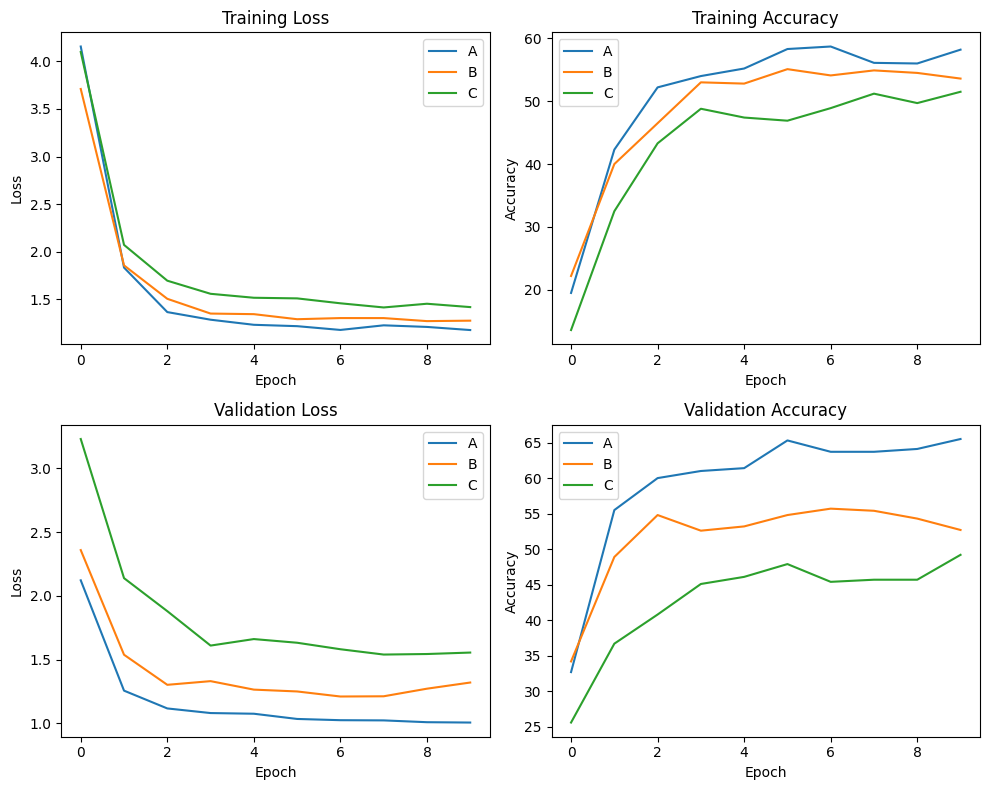

In [16]:
plot_graphs([(i, fashion_results[i]) for i in fashion_results.keys()], save_path = '../../report/images/q2all_fashion.jpg')

In [17]:
def predict(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    preds = []
    
    with torch.no_grad(): 
        for images, labels in dataloader:
            images, labels = images.to(model.device), labels.to(model.device)
            
            outputs = model(images)
            loss = model.criterion(outputs, labels)
            
            loss.item() * images.size(0)

            outputs = model.softmax(outputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            preds.extend(predicted.tolist())

    return preds


In [18]:
model = models[residual][0]
preds = predict(model, test_dataloader)

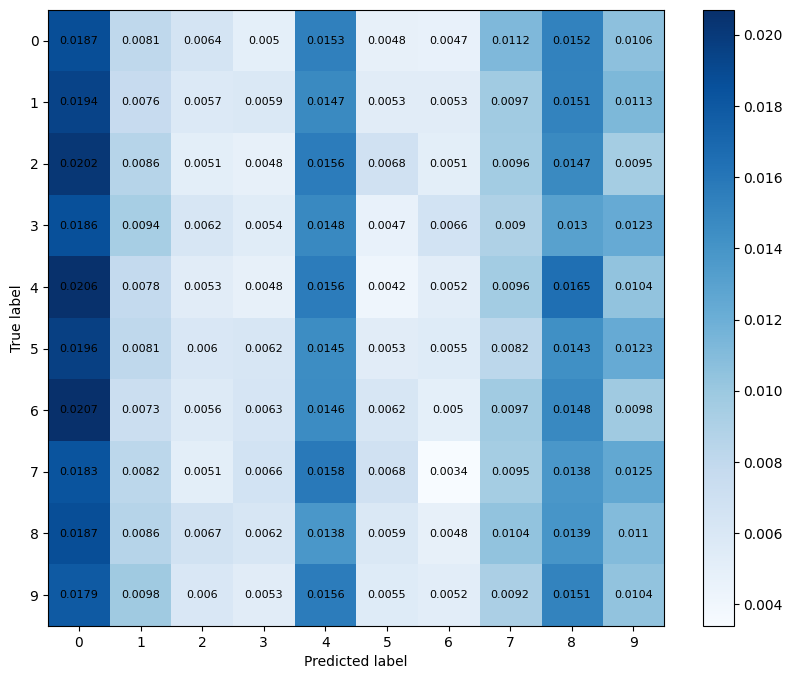

In [19]:
plt.figure(figsize=(10, 8))
plot_confusion_matrix(
    test_dataloader.dataset._y, 
    preds
)
plt.savefig("../../report/images/fashion_mnist_confusion_matrix.png")

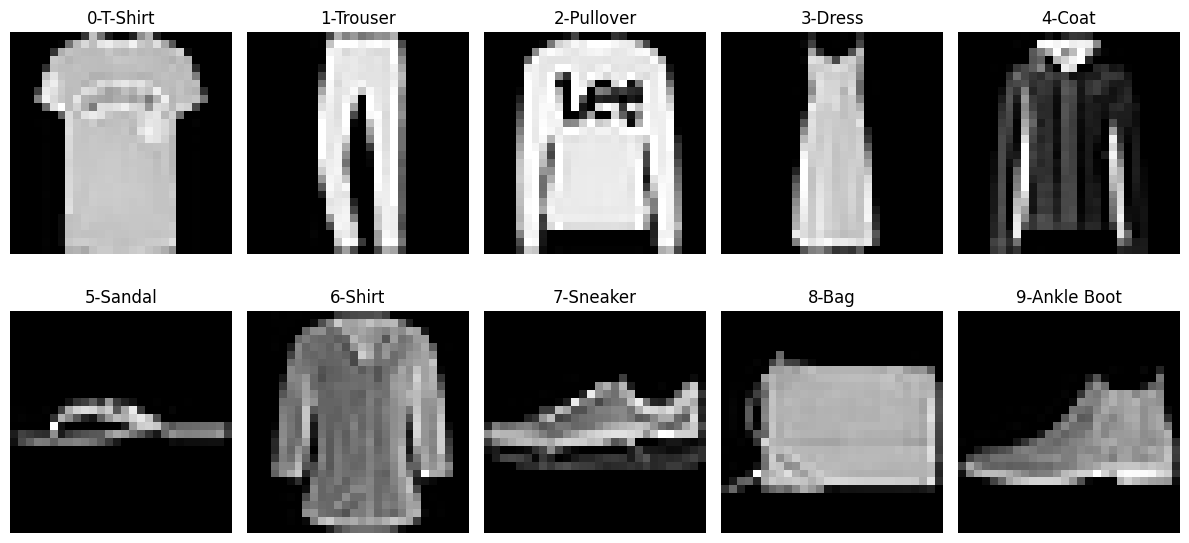

In [20]:

labels_map = {
    0: "T-Shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"
}

def plot_one_of_each(dataset):
    found_labels = {}
    
    for i in range(len(dataset)):
        img, label = dataset[i]
        img = img[0, :, :]
        
        if label not in found_labels:
            found_labels[label] = img
        
        if len(found_labels) == 10:
            break

    _, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.flatten()

    for label in sorted(found_labels.keys()):
        img = found_labels[label]
        
        axes[label].imshow(img, cmap="gray")
        axes[label].set_title(f"{label}-{labels_map[label]}")
        axes[label].axis("off")

    plt.tight_layout()

plot_one_of_each(test_dataloader.dataset)
plt.savefig("../../report/images/fashion_mnist_samples.png")